# Figure S2-S6: IQM differences across scanner manufacturers

This notebook summarizes each image quality metric (IQM) across scanner manufacturers and groups the panels by the Figure 7 metric families.


In [9]:
suppressPackageStartupMessages({
  library(dplyr)
  library(tidyr)
  library(ggplot2)
  library(fs)
  library(jsonlite)
  library(stringr)
  library(purrr)
  library(readr)
  library(arrow)
})

find_config_path <- function() {
  env_path <- Sys.getenv("CONFIG_PATH", unset = "")
  if (nzchar(env_path) && file.exists(env_path)) {
    return(normalizePath(env_path, winslash = "/", mustWork = TRUE))
  }

  d <- normalizePath(getwd(), winslash = "/", mustWork = TRUE)
  repeat {
    cand <- file.path(d, "config.json")
    if (file.exists(cand)) {
      return(normalizePath(cand, winslash = "/", mustWork = TRUE))
    }
    parent <- dirname(d)
    if (identical(parent, d)) break
    d <- parent
  }

  stop("Could not locate config.json. Set CONFIG_PATH or launch Jupyter from within the project tree.")
}

config_path <- find_config_path()
config <- jsonlite::fromJSON(config_path)
project_root <- normalizePath(config$project_root, winslash = "/", mustWork = FALSE)
plot_style_file <- fs::path(project_root, "scripts", "utils", "plot_style.R")
if (!file.exists(plot_style_file)) stop("Missing plot style helper: ", plot_style_file)
source(plot_style_file)
plot_style <- get_plot_style(config)
font_family_use <- get_export_font_family()

figure_s2_dir <- fs::path(project_root, "figures", "Supplement", "FigureS2_S6")
fs::dir_create(figure_s2_dir, recurse = TRUE)



In [10]:
iqm_metrics <- c(
  "raw_neighbor_corr", "raw_masked_neighbor_corr",
  "raw_dwi_contrast", "raw_num_bad_slices",
  "raw_coherence_index", "raw_incoherence_index",
  "t1_neighbor_corr", "t1_masked_neighbor_corr",
  "t1_dwi_contrast", "t1_num_bad_slices",
  "t1_coherence_index", "t1_incoherence_index",
  "t1post_neighbor_corr", "t1post_masked_neighbor_corr",
  "t1post_dwi_contrast", "t1post_num_bad_slices",
  "t1post_coherence_index", "t1post_incoherence_index",
  "mean_fd", "max_fd", "max_rotation", "max_translation",
  "max_rel_rotation", "max_rel_translation", "t1_dice_distance",
  "CNR0_mean", "CNR1_mean", "CNR2_mean", "CNR3_mean", "CNR4_mean",
  "CNR0_median", "CNR1_median", "CNR2_median", "CNR3_median", "CNR4_median",
  "CNR0_standard_deviation", "CNR1_standard_deviation", "CNR2_standard_deviation",
  "CNR3_standard_deviation", "CNR4_standard_deviation", "qc_prediction"
)
motion_iqms <- c(
  "mean_fd", "max_fd", "max_rotation", "max_translation",
  "max_rel_rotation", "max_rel_translation"
)

italic_B <- "𝑩"

classify_family <- function(iqm) {
  if (iqm == "qc_prediction") return("Quality Classifier")
  if (iqm == "t1_dice_distance") return("Coregistration")
  if (iqm %in% motion_iqms) return("Motion")
  if (str_detect(iqm, "^CNR[0-4]_")) return("tSNR/CNR")
  if (str_detect(iqm, "neighbor_corr")) return("Neighbor Corr")
  if (str_detect(iqm, "dwi_contrast")) return("dMRI Contrast")
  if (str_detect(iqm, "num_bad_slices")) return("Bad Slices")
  if (str_detect(iqm, "coherence_index") || str_detect(iqm, "incoherence_index")) return("Coherence/Incoherence")
  "Other"
}

cnr_shell_label <- function(shell_id) {
  switch(shell_id,
    "0" = "tSNR (b=0)",
    "1" = "CNR (b=500)",
    "2" = "CNR (b=1000)",
    "3" = "CNR (b=2000)",
    "4" = "CNR (b=3000)",
    "CNR"
  )
}

format_iqm_label <- function(iqm) {
  if (iqm == "qc_prediction") return("Quality Classifier Score")
  if (iqm == "t1_dice_distance") return("dMRI-T1w Dice Distance")
  if (iqm %in% motion_iqms) {
    name_map <- c(
      "mean_fd" = "Mean Framewise Displacement",
      "max_fd" = "Max Framewise Displacement",
      "max_rotation" = "Max Rotation",
      "max_translation" = "Max Translation",
      "max_rel_rotation" = "Max Relative Rotation (Derivative)",
      "max_rel_translation" = "Max Relative Translation (Derivative)"
    )
    return(unname(name_map[[iqm]]))
  }
  if (str_detect(iqm, "^CNR[0-4]_(mean|median|standard_deviation)$")) {
    shell_id <- str_match(iqm, "^CNR([0-4])_")[, 2]
    stat <- str_match(iqm, "^(?:CNR[0-4]_)(mean|median|standard_deviation)$")[, 2]
    stat_label <- dplyr::recode(stat, mean = "Mean", median = "Median", standard_deviation = "SD")
    return(paste(cnr_shell_label(shell_id), stat_label))
  }

  prefix <- dplyr::case_when(
    str_starts(iqm, "raw_") ~ "Raw",
    str_starts(iqm, "t1post_") ~ paste0("Preprocessed, post-", italic_B, "1"),
    str_starts(iqm, "t1_") ~ paste0("Preprocessed, pre-", italic_B, "1"),
    TRUE ~ ""
  )
  base <- iqm %>% str_remove("^raw_") %>% str_remove("^t1post_") %>% str_remove("^t1_")
  is_masked <- str_starts(base, "masked_")
  core_base <- if (is_masked) str_remove(base, "^masked_") else base
  base_label <- dplyr::case_when(
    core_base == "neighbor_corr" ~ "Neighboring dMRI Correlation",
    core_base == "dwi_contrast" ~ "dMRI Contrast",
    core_base == "num_bad_slices" ~ "Number of Bad Slices",
    core_base == "coherence_index" ~ "Coherence Index",
    core_base == "incoherence_index" ~ "Incoherence Index",
    TRUE ~ core_base
  )

  qualifiers <- character(0)
  if (nzchar(prefix)) qualifiers <- c(qualifiers, prefix)
  if (is_masked) qualifiers <- c(qualifiers, "Masked")


  if (length(qualifiers) > 0) paste0(base_label, " (", paste(qualifiers, collapse = ", "), ")") else base_label
}

family_order <- c(
  "Neighbor Corr",
  "dMRI Contrast",
  "Coherence/Incoherence",
  "Bad Slices",
  "Motion",
  "tSNR/CNR",
  "Coregistration",
  "Quality Classifier"
)
iqm_dict <- tibble(iqm = iqm_metrics) %>%
  mutate(
    family = factor(map_chr(iqm, classify_family), levels = family_order),
    iqm_label = map_chr(iqm, format_iqm_label)
  )


In [11]:
harm_path <- fs::path(project_root, "data", "harmonized_data", "merged_data_meisler_analyses_harmonized.parquet")
if (!file.exists(harm_path)) stop("Missing harmonized data parquet: ", harm_path)

needed_cols <- c("scanner_manufacturer", iqm_metrics)
schema_names <- arrow::open_dataset(harm_path, format = "parquet")$schema$names
missing_cols <- setdiff(needed_cols, schema_names)
if (length(missing_cols) > 0) {
  stop("Harmonized parquet missing required columns: ", paste(missing_cols, collapse = ", "))
}

vendor_order <- c("Siemens", "GE", "Philips")

df_long <- arrow::read_parquet(harm_path, col_select = needed_cols) %>%
  mutate(scanner_manufacturer = as.character(scanner_manufacturer)) %>%
  filter(!is.na(scanner_manufacturer), scanner_manufacturer %in% vendor_order) %>%
  pivot_longer(cols = all_of(iqm_metrics), names_to = "iqm", values_to = "value") %>%
  mutate(value = suppressWarnings(as.numeric(value))) %>%
  filter(!is.na(value)) %>%
  left_join(iqm_dict, by = "iqm") %>%
  mutate(
    scanner_manufacturer = factor(scanner_manufacturer, levels = vendor_order),
    family = factor(family, levels = family_order),
    iqm_label = factor(iqm_label, levels = unique(iqm_dict$iqm_label))
  )

summary_df <- df_long %>%
  group_by(family, iqm_label, scanner_manufacturer) %>%
  summarise(
    n = dplyr::n(),
    mean_value = mean(value, na.rm = TRUE),
    se = stats::sd(value, na.rm = TRUE) / sqrt(n),
    .groups = "drop"
  )


[SAVED] /Users/stevenmeisler/Documents/Penn/abcc-qsiprep/meisler_abcd_dmri/figures/Supplement/FigureS2_S6/S2_neighbor_corr_scanner_vendor_violin.pdf

[SAVED] /Users/stevenmeisler/Documents/Penn/abcc-qsiprep/meisler_abcd_dmri/figures/Supplement/FigureS2_S6/S2_neighbor_corr_scanner_vendor_violin.png



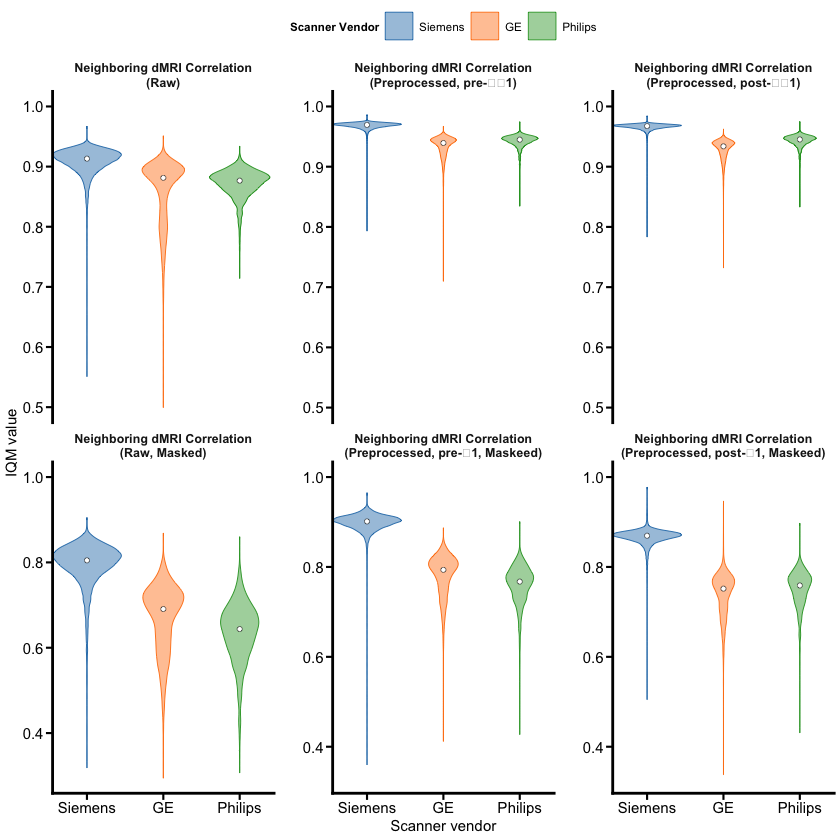

[SAVED] /Users/stevenmeisler/Documents/Penn/abcc-qsiprep/meisler_abcd_dmri/figures/Supplement/FigureS2_S6/S3_dwi_contrast_scanner_vendor_violin.pdf

[SAVED] /Users/stevenmeisler/Documents/Penn/abcc-qsiprep/meisler_abcd_dmri/figures/Supplement/FigureS2_S6/S3_dwi_contrast_scanner_vendor_violin.png



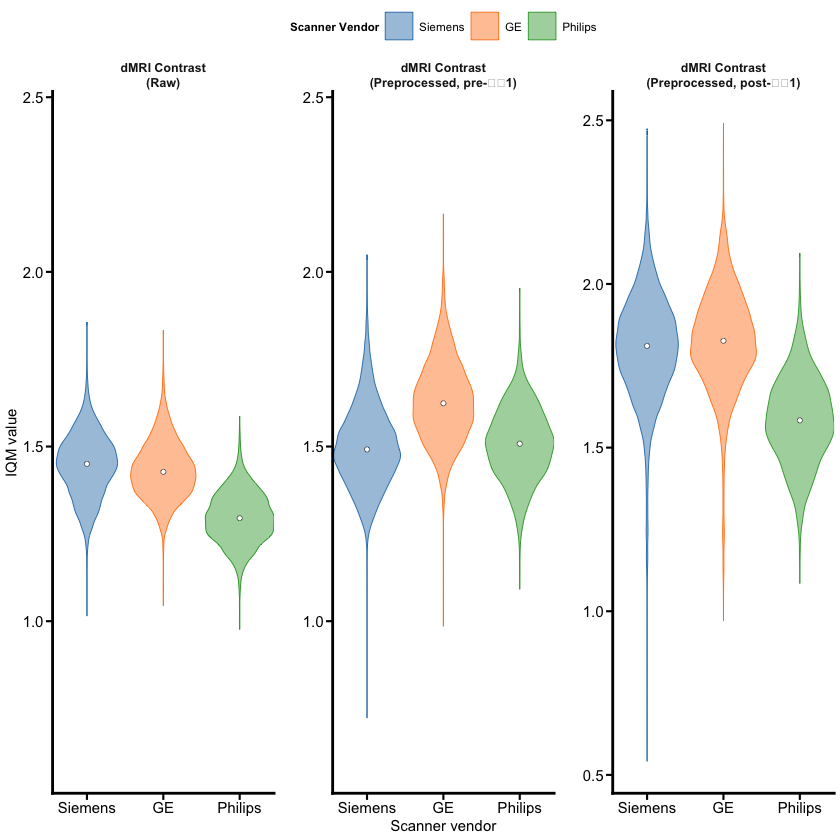

[SAVED] /Users/stevenmeisler/Documents/Penn/abcc-qsiprep/meisler_abcd_dmri/figures/Supplement/FigureS2_S6/S4_motion_coregistration_scanner_vendor_violin.pdf

[SAVED] /Users/stevenmeisler/Documents/Penn/abcc-qsiprep/meisler_abcd_dmri/figures/Supplement/FigureS2_S6/S4_motion_coregistration_scanner_vendor_violin.png



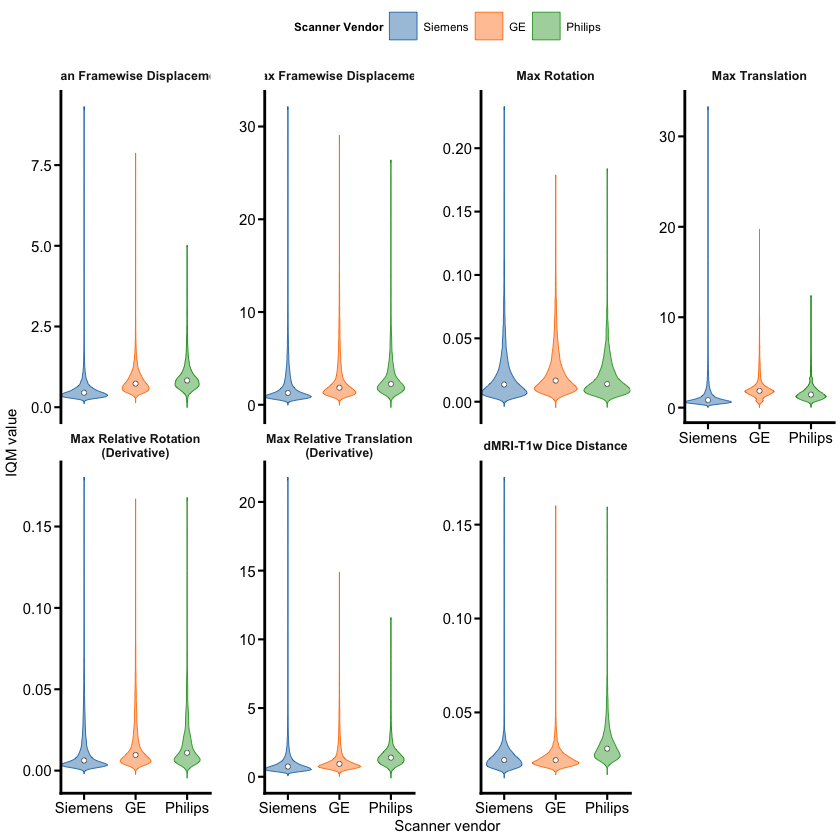

[SAVED] /Users/stevenmeisler/Documents/Penn/abcc-qsiprep/meisler_abcd_dmri/figures/Supplement/FigureS2_S6/S5_coherence_incoherence_scanner_vendor_violin.pdf

[SAVED] /Users/stevenmeisler/Documents/Penn/abcc-qsiprep/meisler_abcd_dmri/figures/Supplement/FigureS2_S6/S5_coherence_incoherence_scanner_vendor_violin.png



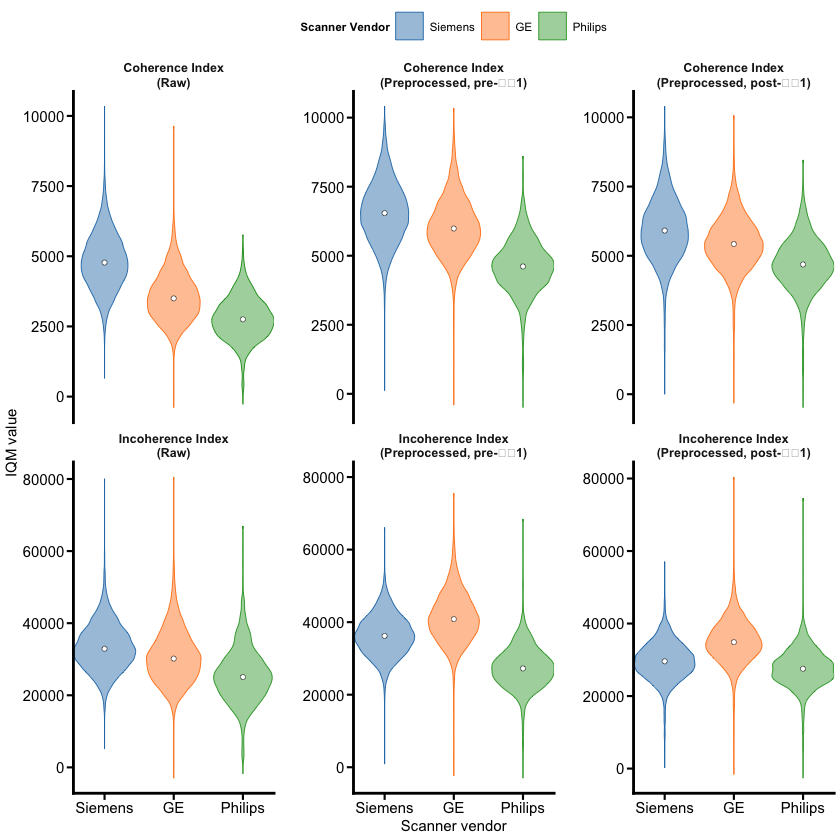

[SAVED] /Users/stevenmeisler/Documents/Penn/abcc-qsiprep/meisler_abcd_dmri/figures/Supplement/FigureS2_S6/S6_bad_slices_scanner_vendor_violin.pdf

[SAVED] /Users/stevenmeisler/Documents/Penn/abcc-qsiprep/meisler_abcd_dmri/figures/Supplement/FigureS2_S6/S6_bad_slices_scanner_vendor_violin.png



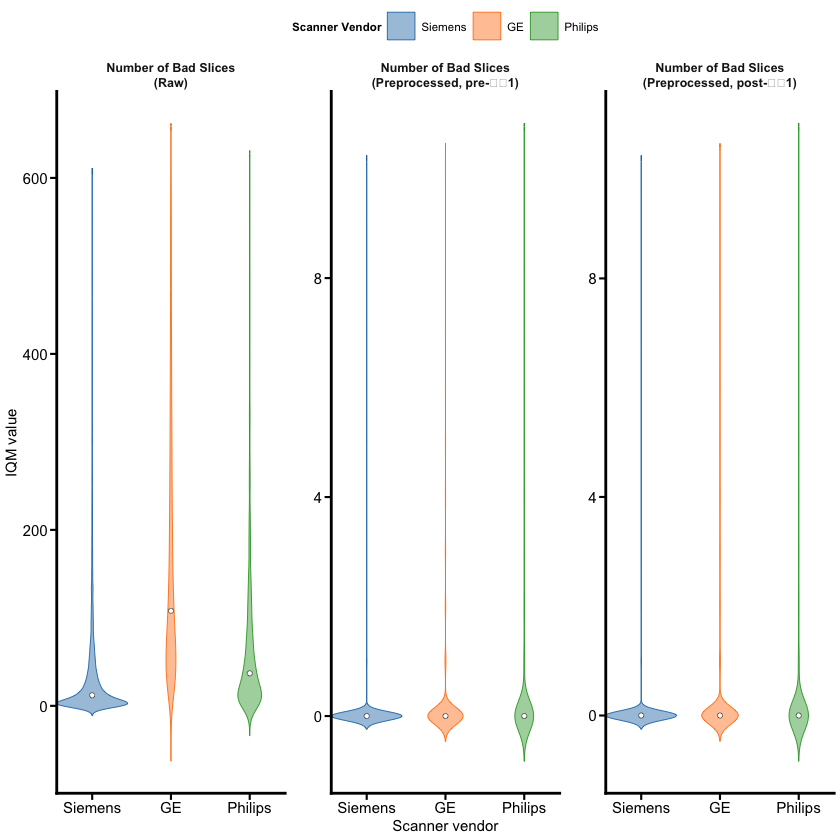

In [ ]:

figure_groups <- list(
  neighbor_corr = c("Neighbor Corr"),
  dwi_contrast = c("dMRI Contrast"),
  motion_coregistration = c("Motion", "Coregistration"),
  coherence_incoherence = c("Coherence/Incoherence"),
  bad_slices = c("Bad Slices")
)

vendor_levels <- c("Siemens", "GE", "Philips")
vendor_pairs <- tibble::tibble(pair = combn(vendor_levels, 2, simplify = FALSE)) %>%
  mutate(
    group1 = map_chr(pair, 1),
    group2 = map_chr(pair, 2)
  ) %>%
  select(group1, group2)

pairwise_stats_all <- df_long %>%
  filter(scanner_manufacturer %in% vendor_levels) %>%
  group_by(iqm, iqm_label) %>%
  group_modify(~ {
    pair_results <- vendor_pairs %>%
      rowwise() %>%
      mutate(
        p_value = {
          x <- .x$value[.x$scanner_manufacturer == group1]
          y <- .x$value[.x$scanner_manufacturer == group2]
          if (length(na.omit(x)) < 2 || length(na.omit(y)) < 2) {
            NA_real_
          } else {
            suppressWarnings(stats::wilcox.test(x, y, exact = FALSE)$p.value)
          }
        }
      ) %>%
      ungroup()
    pair_results
  }) %>%
  ungroup() %>%
  mutate(
    p_adj = p.adjust(p_value, method = "fdr"),
    ns_flag = !is.na(p_adj) & p_adj > 0.05,
    marker = ifelse(ns_flag, "ns", NA_character_)
  )

compute_panel_limits <- function(group_df, group_name) {
  limits <- group_df %>%
    group_by(iqm_label_wrapped) %>%
    summarise(
      iqm = first(as.character(iqm)),
      y_data_min = min(value, na.rm = TRUE),
      y_data_max = max(value, na.rm = TRUE),
      .groups = "drop"
    ) %>%
    mutate(
      y_min_limit = y_data_min,
      y_max_limit = y_data_max
    )

  if (group_name == "neighbor_corr") {
    is_masked <- stringr::str_detect(limits$iqm, "masked_neighbor_corr")
    limits <- limits %>%
      mutate(
        y_min_limit = ifelse(is_masked, 0.33, 0.5),
        y_max_limit = 1
      )
  }

  if (group_name == "dwi_contrast") {
    y_min_global <- min(limits$y_data_min, na.rm = TRUE)
    y_max_global <- max(limits$y_data_max, na.rm = TRUE)
    limits <- limits %>%
      mutate(
        y_min_limit = y_min_global,
        y_max_limit = y_max_global
      )
  }

  if (group_name == "coherence_incoherence") {
    coherence_idx <- stringr::str_detect(limits$iqm, "_coherence_index$")
    incoherence_idx <- stringr::str_detect(limits$iqm, "_incoherence_index$")

    limits <- limits %>%
      mutate(
        y_min_limit = case_when(
          coherence_idx ~ 0,
          incoherence_idx ~ 0,
          TRUE ~ y_min_limit
        ),
        y_max_limit = case_when(
          coherence_idx ~ 10000,
          incoherence_idx ~ 80000,
          TRUE ~ y_max_limit
        )
      )
  }

  if (group_name == "bad_slices") {
    limits <- limits %>%
      mutate(
        y_min_limit = 0,
        y_max_limit = ifelse(stringr::str_detect(iqm, "^raw_"), 600, 10)
      )
  }

  limits
}

build_group_plot <- function(group_df, ns_ann_df, panel_limits, n_rows = 1) {

  limit_df <- bind_rows(
    panel_limits %>% transmute(iqm_label_wrapped, y_limit = y_min_limit),
    panel_limits %>% transmute(iqm_label_wrapped, y_limit = y_max_limit)
  ) %>%
    mutate(scanner_manufacturer = factor(vendor_levels[1], levels = vendor_levels))

  p <- ggplot(group_df, aes(x = scanner_manufacturer, y = value_plot, fill = scanner_manufacturer, color = scanner_manufacturer)) +
    geom_blank(data = limit_df, aes(x = scanner_manufacturer, y = y_limit), inherit.aes = FALSE) +
    geom_violin(trim = FALSE, alpha = 0.45, linewidth = 0.25, na.rm = TRUE) +
    stat_summary(fun = median, geom = "point", shape = 21, size = 1.3, stroke = 0.2, fill = "white", color = "black", na.rm = TRUE) +
    facet_wrap(~iqm_label_wrapped, nrow = n_rows, scales = "free_y") +
    scale_fill_manual(
      name = "Scanner Vendor",
      values = c("Siemens" = "#1f77b4", "GE" = "#ff7f0e", "Philips" = "#2ca02c"),
      drop = FALSE
    ) +
    scale_color_manual(
      name = "Scanner Vendor",
      values = c("Siemens" = "#1f77b4", "GE" = "#ff7f0e", "Philips" = "#2ca02c"),
      drop = FALSE
    ) +
    scale_x_discrete(expand = expansion(mult = c(0.12, 0.12))) +
    labs(
      x = "Scanner Vendor",
      y = "IQM value"
    ) +
    make_theme_pub(
      style = plot_style,
      legend_position = "top",
      axis_title_pt = 9,
      axis_text_pt = 9,
      plot_title_pt = 7,
      legend_title_pt = 7,
      legend_text_pt = 7,
      base_size_pt = 7
    ) +
    theme(
      text = element_text(family = font_family_use),
      axis.text.x = element_text(angle = 0, hjust = 0.5),
      panel.grid.major.x = element_blank(),
      strip.text = element_text(size = 7.5, lineheight = 0.95),
      strip.background = element_blank(),
      panel.spacing.x = grid::unit(1.2, "lines"),
      strip.placement = "outside"
    )

  if (nrow(ns_ann_df) > 0) {
    p <- p +
      geom_segment(
        data = ns_ann_df,
        aes(x = x1, xend = x2, y = y, yend = y),
        inherit.aes = FALSE,
        linewidth = 0.25,
        color = "black"
      ) +
      geom_text(
        data = ns_ann_df,
        aes(x = x_mid, y = y + y_text_offset, label = marker),
        inherit.aes = FALSE,
        size = 2,
        color = "black"
      )
  }

  p
}

format_strip_label <- function(lbl) {
  lbl_clean <- stringr::str_squish(stringr::str_replace_all(as.character(lbl), "\n", " "))
  stringr::str_replace(lbl_clean, " (\\(.*\\))$", "\n\\1")
}

group_names <- names(figure_groups)

plot_outputs <- purrr::map2(group_names, seq_along(group_names), function(group_name, plot_idx) {
  group_families <- figure_groups[[group_name]]
  figure_number <- plot_idx + 1

  group_iqms <- iqm_dict %>%
    filter(family %in% group_families) %>%
    pull(iqm)

  group_df <- df_long %>%
    filter(iqm %in% group_iqms)

  base_labels <- iqm_dict %>%
    filter(iqm %in% group_iqms) %>%
    pull(iqm_label)

  if (group_name == "neighbor_corr") {
    unmasked_labels <- iqm_dict %>%
      filter(iqm %in% group_iqms & str_detect(iqm, "neighbor_corr") & !str_detect(iqm, "masked_neighbor_corr")) %>%
      pull(iqm_label)
    masked_labels <- iqm_dict %>%
      filter(iqm %in% group_iqms & str_detect(iqm, "masked_neighbor_corr")) %>%
      pull(iqm_label)
    base_labels <- c(unmasked_labels, masked_labels)
  }

  if (group_name == "coherence_incoherence") {
    coherence_labels <- iqm_dict %>%
      filter(iqm %in% group_iqms & str_detect(iqm, "_coherence_index$")) %>%
      pull(iqm_label)
    incoherence_labels <- iqm_dict %>%
      filter(iqm %in% group_iqms & str_detect(iqm, "_incoherence_index$")) %>%
      pull(iqm_label)
    base_labels <- c(coherence_labels, incoherence_labels)
  }

  wrapped_levels <- unique(format_strip_label(base_labels))

  group_df <- group_df %>%
    mutate(
      iqm_label_wrapped = factor(
        format_strip_label(as.character(iqm_label)),
        levels = wrapped_levels
      )
    )

  if (nrow(group_df) == 0) {
    warning("No rows found for Figure S2 group: ", group_name)
    return(NULL)
  }

  panel_limits <- compute_panel_limits(group_df, group_name = group_name)
  group_df <- group_df %>%
    left_join(panel_limits %>% select(iqm_label_wrapped, y_min_limit, y_max_limit), by = "iqm_label_wrapped") %>%
    mutate(value_plot = ifelse(value < y_min_limit | value > y_max_limit, NA_real_, value))


  ns_ann_df <- pairwise_stats_all %>%
    filter(iqm %in% group_iqms, ns_flag) %>%
    mutate(
      iqm_label_wrapped = factor(
        format_strip_label(as.character(iqm_label)),
        levels = wrapped_levels
      ),
      x1 = match(group1, vendor_levels),
      x2 = match(group2, vendor_levels),
      x_mid = (x1 + x2) / 2
    )

  panel_ranges <- panel_limits %>%
    transmute(
      iqm_label_wrapped,
      y_min = y_min_limit,
      y_max = y_max_limit
    ) %>%
    mutate(
      y_span = pmax(y_max - y_min, pmax(abs(y_max), 1) * 0.05),
      y_base = y_max - 0.08 * y_span,
      y_step = -0.08 * y_span,
      y_text_offset = 0.015 * y_span
    )

  ns_ann_df <- ns_ann_df %>%
    arrange(iqm_label_wrapped, group1, group2) %>%
    group_by(iqm_label_wrapped) %>%
    mutate(comp_idx = row_number()) %>%
    ungroup() %>%
    left_join(panel_ranges, by = "iqm_label_wrapped") %>%
    mutate(y = y_base + (comp_idx - 1) * y_step)

  n_panels <- dplyr::n_distinct(group_df$iqm_label_wrapped)
  n_rows <- ifelse(n_panels > 3, 2, 1)
  n_cols <- ceiling(n_panels / n_rows)

  p_group <- build_group_plot(group_df, ns_ann_df = ns_ann_df, panel_limits = panel_limits, n_rows = n_rows)
  print(p_group)

  width_in <- max(9, min(18, 2.2 * n_cols + 3.0))
  height_in <- ifelse(n_rows == 2, 6.8, 4.9)

  save_plot_outputs(
    plot_obj = p_group,
    stub = paste0("S", figure_number, "_", group_name, "_scanner_vendor_violin"),
    out_dir = figure_s2_dir,
    width_in = width_in,
    height_in = height_in
  )
})
